<a href="https://colab.research.google.com/github/rijuvanak/Project/blob/main/gflownet/MULTI_OBJECTIVE_GFLOWNET_PIPELINEsc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit minisom openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 42.3 MB/s eta 0:00:00
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=462296cd937fde905c547b703ac6c45774736043987e3381ba4ccc769877ecab
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
from rdkit import Chem
print("RDKit installed correctly")

RDKit installed correctly


In [ ]:
# =========================================================
# MULTI-OBJECTIVE GFLOWNET PIPELINE
#
# PART 1:
# LSTM Toxicity Predictor
#
# Output:
# SMILES --> Safety probability
#
# =========================================================


# Install requirements
!pip -q install scikit-learn tqdm rdkit-pypi openpyxl


# =========================================================
# IMPORTS
# =========================================================

import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from google.colab import files


# =========================================================
# DEVICE
# =========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


# =========================================================
# PARAMETERS
# =========================================================

BATCH = 256
EPOCHS = 6

MAX_LEN = 120



# =========================================================
# SMILES VALIDATION
# =========================================================

ALLOWED = set(
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "abcdefghijklmnopqrstuvwxyz"
    "0123456789"
    "#=[]()+-@./"
)


def valid_smiles(s):

    return (
        isinstance(s,str)
        and 2 <= len(s) <= 150
        and all(c in ALLOWED for c in s)
    )



# =========================================================
# LOAD TOXICITY DATASET
# =========================================================


print(
    "Upload toxicity CSV containing:"
    "\nSMILES"
    "\ntox_val"
)


uploaded = files.upload()


tox_file = list(uploaded.keys())[0]


df = pd.read_csv(tox_file)



# remove missing data

df = df.dropna(
    subset=[
        "SMILES",
        "tox_val"
    ]
)


# remove invalid smiles

df = df[
    df.SMILES.apply(valid_smiles)
]



print(
    "Total molecules:",
    len(df)
)



# =========================================================
# CREATE TOXICITY LABELS
# =========================================================

# Median split
# 1 = safe
# 0 = toxic


threshold = df.tox_val.median()


df["label"] = (
    df.tox_val <= threshold
).astype(int)



print(
    "Toxicity threshold:",
    threshold
)


print(
    df.label.value_counts()
)



# =========================================================
# TRAIN TEST SPLIT
# =========================================================


idx = np.random.permutation(
    len(df)
)


split = int(
    0.8 * len(df)
)



train_df = df.iloc[
    idx[:split]
]


test_df = df.iloc[
    idx[split:]
]


print(
    "Train:",
    len(train_df)
)


print(
    "Test:",
    len(test_df)
)




# =========================================================
# SMILES VOCABULARY
# =========================================================


special_tokens = [
    "<PAD>",
    "<START>",
    "<END>"
]


characters = sorted(
    set(
        "".join(
            train_df.SMILES
        )
    )
)


vocab = (
    special_tokens
    +
    characters
)



stoi = {
    c:i
    for i,c in enumerate(vocab)
}



itos = {
    i:c
    for c,i in stoi.items()
}



PAD = 0
START = 1
END = 2



VOCAB_SIZE = len(vocab)



print(
    "Vocabulary size:",
    VOCAB_SIZE
)




# =========================================================
# ENCODING FUNCTIONS
# =========================================================


def encode(smiles):

    tokens = [
        START
    ]


    for c in smiles:

        if c in stoi:

            tokens.append(
                stoi[c]
            )


    tokens.append(
        END
    )


    return tokens




def pad_sequences(batch):

    max_len = max(
        len(x)
        for x in batch
    )


    arr = np.full(
        (
            len(batch),
            max_len
        ),
        PAD
    )


    for i,x in enumerate(batch):

        arr[i,:len(x)] = x



    return torch.tensor(
        arr,
        dtype=torch.long
    ).to(DEVICE)



# =========================================================
# LSTM TOXICITY CLASSIFIER
# =========================================================


class ToxicityLSTM(nn.Module):

    def __init__(self):

        super().__init__()


        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            128
        )


        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            batch_first=True
        )


        self.fc = nn.Linear(
            256,
            1
        )



    def forward(self,x):

        emb = self.embedding(x)


        out,_ = self.lstm(
            emb
        )


        last = out[:,-1,:]


        return self.fc(
            last
        )





# create model

tox_model = ToxicityLSTM().to(DEVICE)


optimizer = optim.Adam(
    tox_model.parameters(),
    lr=1e-3
)


loss_function = nn.BCEWithLogitsLoss()




# =========================================================
# TRAIN LSTM
# =========================================================


train_sequences = [
    encode(s)
    for s in train_df.SMILES
]


train_labels = (
    train_df.label.values
)



print("\nTraining toxicity model...")


for epoch in range(EPOCHS):


    tox_model.train()


    total_loss = 0



    for i in range(
        0,
        len(train_sequences),
        BATCH
    ):


        batch_seq = train_sequences[
            i:i+BATCH
        ]


        x = pad_sequences(
            batch_seq
        )


        y = torch.tensor(
            train_labels[
                i:i+BATCH
            ],
            dtype=torch.float32
        ).to(DEVICE)



        output = tox_model(x).squeeze()


        loss = loss_function(
            output,
            y
        )



        optimizer.zero_grad()

        loss.backward()

        optimizer.step()



        total_loss += loss.item()



    print(
        f"Epoch {epoch+1}/{EPOCHS}",
        "Loss:",
        round(total_loss,3)
    )




# =========================================================
# SAFETY PROBABILITY FUNCTION
# =========================================================


def predict_safety(smiles_list):


    tox_model.eval()


    sequences = [
        encode(s)
        for s in smiles_list
    ]


    predictions = []



    with torch.no_grad():


        for i in range(
            0,
            len(sequences),
            BATCH
        ):


            x = pad_sequences(
                sequences[i:i+BATCH]
            )


            prob = torch.sigmoid(
                tox_model(x)
            )


            predictions.extend(
                prob.cpu()
                .numpy()
                .flatten()
            )



    return np.array(
        predictions
    )




# =========================================================
# TEST PERFORMANCE
# =========================================================


test_prob = predict_safety(
    test_df.SMILES.tolist()
)


test_pred = (
    test_prob > 0.5
).astype(int)



print("\n========== TOXICITY MODEL RESULTS ==========")


print(
    "Accuracy:",
    accuracy_score(
        test_df.label,
        test_pred
    )
)


print(
    "Precision:",
    precision_score(
        test_df.label,
        test_pred
    )
)


print(
    "Recall:",
    recall_score(
        test_df.label,
        test_pred
    )
)


print(
    "F1:",
    f1_score(
        test_df.label,
        test_pred
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        test_df.label,
        test_prob
    )
)



print(
    "\nPART 1 COMPLETE"
)

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi
Device: cpu
Upload toxicity CSV containing:
SMILES
tox_val


Saving toxicity_with_smiles.csv to toxicity_with_smiles.csv
Total molecules: 51592
Toxicity threshold: 3.9
label
1    25851
0    25741
Name: count, dtype: int64
Train: 41273
Test: 10319
Vocabulary size: 63

Training toxicity model...
Epoch 1/6 Loss: 112.532
Epoch 2/6 Loss: 112.304
Epoch 3/6 Loss: 112.28
Epoch 4/6 Loss: 112.264
Epoch 5/6 Loss: 112.241
Epoch 6/6 Loss: 112.235

========== TOXICITY MODEL RESULTS ==========
Accuracy: 0.5073166004457796
Precision: 0.5070559610705596
Recall: 0.9963664180531651
F1: 0.6720846233230134
ROC-AUC: 0.49889448335018444

PART 1 COMPLETE


In [ ]:
predict_safety(["CCO"])

array([0.4653181], dtype=float32)

In [ ]:
# =========================================================
# MULTI-OBJECTIVE GFLOWNET PIPELINE
#
# PART 2:
# FDA + NF-kB Chemical Space Reward
#
# Creates:
# 1. FDA similarity score
# 2. NF-kB similarity score
# 3. Combined reward
#
# =========================================================


# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np

from google.colab import files

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem



# =========================================================
# REWARD WEIGHTS
# =========================================================


W_TOX = 0.60
W_FDA = 0.25
W_NFKB = 0.15



print(
    "Reward:"
)

print(
    f"Toxicity  : {W_TOX}"
)

print(
    f"FDA       : {W_FDA}"
)

print(
    f"NF-kB     : {W_NFKB}"
)




# =========================================================
# SMILES COLUMN FINDER
# =========================================================


def find_smiles_column(df):

    for col in df.columns:

        if "SMILES" in col.upper():

            return col


    raise ValueError(
        "No SMILES column found"
    )





# =========================================================
# LOAD FDA MOLECULES
# =========================================================


print(
    "\nUpload FDA approved molecule CSV"
)


upload = files.upload()


fda_file = list(upload.keys())[0]


fda_df = pd.read_csv(
    fda_file,
    encoding="latin1"
)



fda_col = find_smiles_column(
    fda_df
)



fda_smiles = (
    fda_df[fda_col]
    .dropna()
    .astype(str)
    .tolist()
)



print(
    "FDA molecules:",
    len(fda_smiles)
)





# =========================================================
# LOAD NF-kB ACTIVE MOLECULES
# =========================================================


print(
    "\nUpload NF-kB active molecule CSV"
)


upload = files.upload()


nfkb_file = list(upload.keys())[0]


nfkb_df = pd.read_csv(
    nfkb_file,
    encoding="latin1"
)



nfkb_col = find_smiles_column(
    nfkb_df
)



nfkb_smiles = (
    nfkb_df[nfkb_col]
    .dropna()
    .astype(str)
    .tolist()
)



print(
    "NF-kB molecules:",
    len(nfkb_smiles)
)





# =========================================================
# MORGAN FINGERPRINT SETTINGS
# =========================================================


RADIUS = 2

N_BITS = 2048




def smiles_to_fp(smiles):


    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        return None



    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    return fp





# =========================================================
# CREATE FDA / NF-kB FINGERPRINT LIBRARIES
# =========================================================


FDA_FPS=[]

for smi in fda_smiles:

    fp = smiles_to_fp(smi)

    if fp is not None:

        FDA_FPS.append(fp)



NFKB_FPS=[]

for smi in nfkb_smiles:

    fp = smiles_to_fp(smi)

    if fp is not None:

        NFKB_FPS.append(fp)




print(
    "\nValid FDA fingerprints:",
    len(FDA_FPS)
)


print(
    "Valid NF-kB fingerprints:",
    len(NFKB_FPS)
)





# =========================================================
# Tanimoto SIMILARITY FUNCTIONS
# =========================================================


def max_similarity_to_library(
        smiles,
        library_fps):


    fp = smiles_to_fp(
        smiles
    )


    if fp is None:

        return 0.0



    similarities=[]


    for ref_fp in library_fps:


        sim = DataStructs.TanimotoSimilarity(
            fp,
            ref_fp
        )


        similarities.append(
            sim
        )



    return max(
        similarities
    )





# =========================================================
# MULTI OBJECTIVE REWARD FUNCTION
# =========================================================


def calculate_reward(smiles):


    # 1. Toxicity reward

    tox_score = predict_safety(
        [smiles]
    )[0]



    # 2. FDA similarity

    fda_score = max_similarity_to_library(
        smiles,
        FDA_FPS
    )



    # 3. NF-kB similarity

    nfkb_score = max_similarity_to_library(
        smiles,
        NFKB_FPS
    )



    # Combined reward

    total_reward = (

        W_TOX * tox_score

        +

        W_FDA * fda_score

        +

        W_NFKB * nfkb_score

    )



    return {

        "toxicity_score": tox_score,

        "FDA_similarity": fda_score,

        "NFkB_similarity": nfkb_score,

        "total_reward": total_reward

    }





# =========================================================
# TEST REWARD FUNCTION
# =========================================================


example = "CCO"


score = calculate_reward(
    example
)


print(
    "\nExample reward:"
)


for k,v in score.items():

    print(
        k,
        ":",
        round(v,4)
    )



print(
    "\nPART 2 COMPLETE"
)

Reward:
Toxicity  : 0.6
FDA       : 0.25
NF-kB     : 0.15

Upload FDA approved molecule CSV


Saving fda_smiles (1).csv to fda_smiles (1).csv
FDA molecules: 3178

Upload NF-kB active molecule CSV


Saving bioassay_with_smiles.csv to bioassay_with_smiles.csv
NF-kB molecules: 3493


Streaming output truncated to the last 5000 lines.
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:24:10] DEPRECATION WARNING: please use MorganGenerator
[14:2


Valid FDA fingerprints: 3178
Valid NF-kB fingerprints: 3493

Example reward:
toxicity_score : 0.4653
FDA_similarity : 0.3571
NFkB_similarity : 0.1282
total_reward : 0.3877

PART 2 COMPLETE


[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerator
[14:24:12] DEPRECATION WARNING: please use MorganGenerat

Safe training molecules: 20622

Training Multi-objective GFlowNet...


Streaming output truncated to the last 5000 lines.
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] WARNING: not removing hydrogen atom without neighbors
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] WARNING: not removing hydrogen atom without neighbors
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGenerator
[14:35:31] DEPRECATION WARNING: please use MorganGen

Epoch 1 Loss: 6457.183


Streaming output truncated to the last 5000 lines.
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] WARNING: not removing hydrogen atom without neighbors
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] WARNING: not removing hydrogen atom without neighbors
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGenerator
[14:47:37] DEPRECATION WARNING: please use MorganGen

Epoch 2 Loss: 5102.163


...

Epoch 3 Loss: 4764.945


Streaming output truncated to the last 5000 lines.
[15:12:14] WARNING: not removing hydrogen atom without neighbors
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] WARNING: not removing hydrogen atom without neighbors
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:14] DEPRECATION WARNING: please use MorganGenerator
[15:12:15] DEPRECATION WARNING: please use MorganGenerator
[15:12:15] DEPRECATION WARNING: please use MorganGenerator
[15:12:15] DEPRECATION WARNING: please use MorganGen

Epoch 4 Loss: 4592.143


Streaming output truncated to the last 5000 lines.
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] WARNING: not removing hydrogen atom without neighbors
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] WARNING: not removing hydrogen atom without neighbors
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGenerator
[15:24:47] DEPRECATION WARNING: please use MorganGen

Epoch 5 Loss: 4487.717


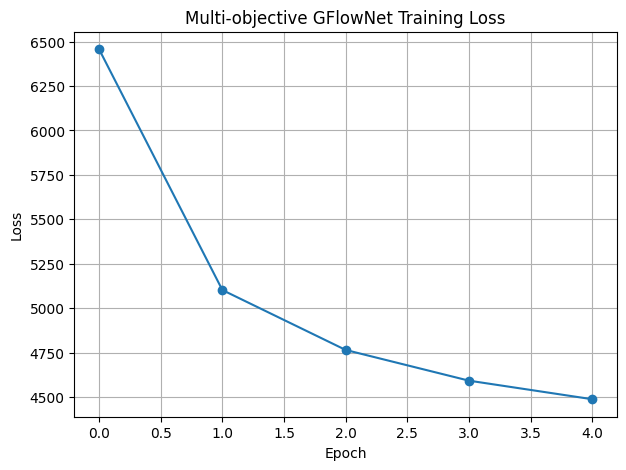


Generating molecules...


100%|██████████| 1000/1000 [00:21<00:00, 45.60it/s]


Generated: 1000
Unique molecules: 522

Scoring generated molecules...


  0%|          | 0/522 [00:00<?, ?it/s][15:26:40] DEPRECATION WARNING: please use MorganGenerator
[15:26:40] DEPRECATION WARNING: please use MorganGenerator
[15:26:41] SMILES Parse Error: extra open parentheses while parsing: Cn1cc(-c2ccc(N)c(F)c3ccc(Oc3c(S(=O)=c(N)cc3c2ccc(N)cc2)cc1)c1ccccc1C2
[15:26:41] SMILES Parse Error: check for mistakes around position 6:
[15:26:41] Cn1cc(-c2ccc(N)c(F)c3ccc(Oc3c(S(=O)=c(N)c
[15:26:41] ~~~~~^
[15:26:41] SMILES Parse Error: Failed parsing SMILES 'Cn1cc(-c2ccc(N)c(F)c3ccc(Oc3c(S(=O)=c(N)cc3c2ccc(N)cc2)cc1)c1ccccc1C2' for input: 'Cn1cc(-c2ccc(N)c(F)c3ccc(Oc3c(S(=O)=c(N)cc3c2ccc(N)cc2)cc1)c1ccccc1C2'
[15:26:41] SMILES Parse Error: extra open parentheses while parsing: Cn1cc(-c2ccc(N)c(F)c3ccc(Oc3c(S(=O)=c(N)cc3c2ccc(N)cc2)cc1)c1ccccc1C2
[15:26:41] SMILES Parse Error: check for mistakes around position 6:
[15:26:41] Cn1cc(-c2ccc(N)c(F)c3ccc(Oc3c(S(=O)=c(N)c
[15:26:41] ~~~~~^
[15:26:41] SMILES Parse Error: Failed parsing SMILES 'Cn1cc(-c2ccc(N)c(F)c3cc


DONE
Saved:
results/generated_multiobjective_ranked.csv
results/top100_generated_candidates.csv


In [ ]:
# =========================================================
# MULTI-OBJECTIVE GFLOWNET PIPELINE
#
# PART 3:
# GFlowNet Training + Generation
#
# Reward:
# 60% Toxicity
# 25% FDA similarity
# 15% NF-kB similarity
#
# =========================================================


import os
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm
import pandas as pd
import numpy as np



# =========================================================
# PREPARE SAFE TRAINING MOLECULES
# =========================================================

# Use low toxicity molecules as starting trajectories

safe_df = train_df[
    train_df.label == 1
]


safe_sequences = [
    encode(s)
    for s in safe_df.SMILES
]


print(
    "Safe training molecules:",
    len(safe_sequences)
)



# =========================================================
# GFLOWNET MODEL
# =========================================================


class GFlowNet(nn.Module):

    def __init__(self):

        super().__init__()


        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            128
        )


        self.lstm = nn.LSTM(
            128,
            256,
            batch_first=True
        )


        self.output = nn.Linear(
            256,
            VOCAB_SIZE
        )



    def forward(self,x):


        x = self.embedding(x)


        out,_ = self.lstm(x)


        logits = self.output(
            out
        )


        return logits





gfn = GFlowNet().to(DEVICE)



optimizer_gfn = optim.Adam(
    gfn.parameters(),
    lr=1e-3
)



# =========================================================
# TRAIN GFLOWNET USING MULTI-OBJECTIVE REWARD
# =========================================================


GFN_EPOCHS = 5



print(
    "\nTraining Multi-objective GFlowNet..."
)



loss_history=[]



for epoch in range(GFN_EPOCHS):


    gfn.train()


    total_loss=0



    for seq in safe_sequences:


        if len(seq)<2:

            continue



        # Convert token sequence back to SMILES

        smi = "".join(
            itos[i]
            for i in seq
            if i > 2
        )



        # ==============================
        # NEW MULTI OBJECTIVE REWARD
        # ==============================

        reward_info = calculate_reward(
            smi
        )


        reward = reward_info[
            "total_reward"
        ]



        x = torch.tensor(
            seq[:-1]
        ).unsqueeze(0).to(DEVICE)



        y = torch.tensor(
            seq[1:]
        ).unsqueeze(0).to(DEVICE)




        logits = gfn(
            x
        )



        log_prob = torch.log_softmax(
            logits,
            dim=-1
        )



        token_logprob = (
            log_prob
            .gather(
                2,
                y.unsqueeze(-1)
            )
            .squeeze(-1)
        )



        loss = (
            -reward *
            token_logprob.mean()
        )



        optimizer_gfn.zero_grad()

        loss.backward()

        optimizer_gfn.step()



        total_loss += loss.item()



    loss_history.append(
        total_loss
    )


    print(
        "Epoch",
        epoch+1,
        "Loss:",
        round(total_loss,3)
    )




# =========================================================
# PLOT GFLOWNET LOSS
# =========================================================


import matplotlib.pyplot as plt



plt.figure(figsize=(7,5))


plt.plot(
    loss_history,
    marker="o"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Multi-objective GFlowNet Training Loss"
)


plt.grid()


plt.savefig(
    "GFN_training_loss.png",
    dpi=300
)


plt.show()





# =========================================================
# MOLECULE GENERATION FUNCTION
# =========================================================


def generate_molecule():


    gfn.eval()


    sequence=[START]



    with torch.no_grad():


        for step in range(100):


            x=torch.tensor(
                sequence
            ).unsqueeze(0).to(DEVICE)



            logits=gfn(x)


            prob=torch.softmax(
                logits[0,-1],
                dim=0
            ).cpu().numpy()



            next_token=np.random.choice(
                len(prob),
                p=prob
            )



            if next_token == END:

                break



            sequence.append(
                next_token
            )




    smiles="".join(
        itos[i]
        for i in sequence
        if i>2
    )



    return smiles





# =========================================================
# GENERATE MOLECULES
# =========================================================


N_GENERATE = 1000



generated=[]



print(
    "\nGenerating molecules..."
)



for i in tqdm(
    range(N_GENERATE)
):


    smi = generate_molecule()



    if valid_smiles(smi):


        generated.append(
            smi
        )




print(
    "Generated:",
    len(generated)
)





# =========================================================
# REMOVE DUPLICATES
# =========================================================


generated = list(
    set(generated)
)



print(
    "Unique molecules:",
    len(generated)
)





# =========================================================
# SCORE GENERATED MOLECULES
# =========================================================


results=[]



print(
    "\nScoring generated molecules..."
)



for smi in tqdm(
    generated
):


    try:


        score = calculate_reward(
            smi
        )


        results.append(
            {

            "SMILES":smi,

            "toxicity_score":
            score["toxicity_score"],

            "FDA_similarity":
            score["FDA_similarity"],

            "NFkB_similarity":
            score["NFkB_similarity"],

            "total_reward":
            score["total_reward"]

            }

        )


    except:

        pass





# =========================================================
# FINAL RANKING
# =========================================================


final_df=pd.DataFrame(
    results
)



final_df = final_df.sort_values(
    "total_reward",
    ascending=False
)



final_df["rank"] = range(
    1,
    len(final_df)+1
)



# =========================================================
# SAVE RESULTS
# =========================================================


os.makedirs(
    "results",
    exist_ok=True
)



final_df.to_csv(
    "results/generated_multiobjective_ranked.csv",
    index=False
)



final_df.head(100).to_csv(
    "results/top100_generated_candidates.csv",
    index=False
)




print(
    "\n================================"
)

print(
    "DONE"
)

print(
    "Saved:"
)

print(
    "results/generated_multiobjective_ranked.csv"
)

print(
    "results/top100_generated_candidates.csv"
)

print(
    "================================"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')